# Разведочный анализ данных (EDA): датасет о самолётах

**Цель работы:** провести разведочный анализ данных, очистить данные, визуализировать распределения признаков, оценить зависимости между ними, выполнить инжиниринг признаков и подготовить данные для последующего моделирования.

**Задача предсказания:** предсказание максимальной скорости (`Maximum Speed (knots)`) по остальным характеристикам самолёта.

**Данные:** [Aircraft Weight and Balance Dataset](https://www.kaggle.com/datasets/...). Содержит 15 столбцов, 25000 записей, пропуски отсутствуют.

## 1. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import re

# Настройки стилей
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
%matplotlib inline

## 2. Загрузка данных и первичный анализ

In [2]:
# Загрузка
df = pd.read_csv('aircraft_dataset.csv')
print(f"Размер данных: {df.shape}\n")
print("Первые 5 строк:")
display(df.head())
print("\nИнформация о данных:")
df.info()
print("\nСтатистики для числовых признаков:")
display(df.describe())
print("\nПропуски в каждом столбце:")
display(df.isnull().sum())

Размер данных: (25000, 15)

Первые 5 строк:


,Unnamed: 0,Aircraft Model,Empty Weight (kg),Maximum Takeoff Weight (kg),Maximum Landing Weight (kg),Center of Gravity Limits,Wing Loading (kg/m²),Tail Loading (kg/m²),Fuel Capacity (liters),Number of Passengers,Cargo Capacity (kg),Maximum Altitude (ft),Maximum Speed (knots),Engine Type,Fuselage Length (m)
0,0,Airbus A320,149968.187455,279525.090979,255896.490294,25%-35% of MAC,818.558281,124.788364,52538.236167,472,80061.732289,44470,658,Turbofan,41.726817
1,1,Boeing 777,140855.879891,145055.173915,143703.314584,15%-30% of MAC,366.423230,111.743182,298000.265987,257,27118.725192,31739,495,Turbofan,54.402799
2,2,Airbus A320,151024.598908,534343.948027,270662.904304,20%-35% of MAC,829.145903,138.672695,176299.254601,172,1002.209110,24398,585,Turboprop,28.864086
3,3,Airbus A320,180889.454772,815185.841349,183594.487162,15%-30% of MAC,290.845909,169.249463,51211.630194,444,75726.083545,26793,632,Turboprop,46.111611
4,4,Embraer E190,113855.173286,439094.342299,233683.883944,20%-35% of MAC,509.848919,32.282885,494662.501258,55,45268.322065,30982,663,Piston,80.394753



Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   25000 non-null  int64  
 1   Aircraft Model               25000 non-null  str    
 2   Empty Weight (kg)            25000 non-null  float64
 3   Maximum Takeoff Weight (kg)  25000 non-null  float64
 4   Maximum Landing Weight (kg)  25000 non-null  float64
 5   Center of Gravity Limits     25000 non-null  str    
 6   Wing Loading (kg/m²)         25000 non-null  float64
 7   Tail Loading (kg/m²)         25000 non-null  float64
 8   Fuel Capacity (liters)       25000 non-null  float64
 9   Number of Passengers         25000 non-null  int64  
 10  Cargo Capacity (kg)          25000 non-null  float64
 11  Maximum Altitude (ft)        25000 non-null  int64  
 12  Maximum Speed (knots)        25000 non-null  int64  
 13  Engin

,Unnamed: 0,Empty Weight (kg),Maximum Takeoff Weight (kg),Maximum Landing Weight (kg),Wing Loading (kg/m²),Tail Loading (kg/m²),Fuel Capacity (liters),Number of Passengers,Cargo Capacity (kg),Maximum Altitude (ft),Maximum Speed (knots),Fuselage Length (m)
count,25000.000000,25000.000000,2.500000e+04,2.500000e+04,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12499.500000,150550.712410,4.526516e+05,3.019565e+05,598.404186,109.806503,249099.077932,274.545560,50152.936766,39961.992880,550.450160,55.058987
std,7217.022701,86463.623898,3.284551e+05,2.323845e+05,231.058661,52.008772,144365.178161,129.985611,28464.768809,11570.426026,86.927584,26.080878
min,0.000000,523.501931,7.081314e+02,6.310162e+02,200.077157,20.019328,1002.584912,50.000000,1002.043840,20001.000000,400.000000,10.004177
25%,6249.750000,75478.577899,1.891280e+05,1.277688e+05,398.572198,64.916463,124086.001976,162.000000,25860.125043,29910.000000,475.000000,32.568153
50%,12499.500000,150022.889154,3.806035e+05,2.548705e+05,596.545232,109.641132,248362.359605,274.000000,49845.885537,39920.500000,551.000000,55.081186
75%,18749.250000,225922.318888,6.600670e+05,4.112665e+05,799.258956,154.733859,374861.477465,387.000000,74845.195460,50000.250000,626.000000,77.718134
max,24999.000000,299996.456246,1.498140e+06,1.435393e+06,999.954641,199.999980,499953.926532,500.000000,99995.241980,60000.000000,700.000000,99.987941



Пропуски в каждом столбце:


Unnamed: 0                     0
Aircraft Model                 0
Empty Weight (kg)              0
Maximum Takeoff Weight (kg)    0
Maximum Landing Weight (kg)    0
Center of Gravity Limits       0
Wing Loading (kg/m²)           0
Tail Loading (kg/m²)           0
Fuel Capacity (liters)         0
Number of Passengers           0
Cargo Capacity (kg)            0
Maximum Altitude (ft)          0
Maximum Speed (knots)          0
Engine Type                    0
Fuselage Length (m)            0
dtype: int64

## 3. Чистка данных (Data Cleaning)

Данные изначально чистые (нет пропусков), но мы всё равно проведём необходимые преобразования:
- Удалим столбец-индекс `Unnamed: 0` (если есть).
- Проверим логическую согласованность: `Empty Weight` < `Maximum Takeoff Weight`.
- Извлечём числовые значения центра тяжести из строкового столбца.
- Заполним возможные пропуски (хотя их нет).

In [3]:
# Удаление столбца-индекса
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
    print("Столбец 'Unnamed: 0' удалён.")

# Удаление дубликатов (проверка)
duplicates = df.duplicated().sum()
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Удалено {duplicates} дубликатов.")
else:
    print("Дубликатов не найдено.")

# Логическая проверка: пустой вес должен быть меньше взлётного
invalid = df[df['Empty Weight (kg)'] >= df['Maximum Takeoff Weight (kg)']]
if len(invalid) > 0:
    df = df[df['Empty Weight (kg)'] < df['Maximum Takeoff Weight (kg)']]
    print(f"Удалено {len(invalid)} записей с некорректным соотношением весов.")
else:
    print("Логическое условие выполнено для всех записей.")

# Извлечение CG из строкового поля
def extract_cg(s):
    nums = re.findall(r'\d+', str(s))
    if len(nums) >= 2:
        return float(nums[0]), float(nums[1])
    else:
        return np.nan, np.nan

df[['CG_min', 'CG_max']] = df['Center of Gravity Limits'].apply(lambda x: pd.Series(extract_cg(x)))
df.drop('Center of Gravity Limits', axis=1, inplace=True)
print("Столбец 'Center of Gravity Limits' преобразован в числовые CG_min и CG_max.")

# Проверка пропусков в числовых столбцах
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nПропуски в числовых столбцах после обработки:")
display(df[numeric_cols].isnull().sum())

# Если всё же есть NaN, заполним медианой (здесь их нет)
for col in numeric_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

print("\nОчистка завершена. Данные готовы.")

Столбец 'Unnamed: 0' удалён.
Дубликатов не найдено.
Логическое условие выполнено для всех записей.
Столбец 'Center of Gravity Limits' преобразован в числовые CG_min и CG_max.

Пропуски в числовых столбцах после обработки:


Empty Weight (kg)              0
Maximum Takeoff Weight (kg)    0
Maximum Landing Weight (kg)    0
Wing Loading (kg/m²)           0
Tail Loading (kg/m²)           0
Fuel Capacity (liters)         0
Number of Passengers           0
Cargo Capacity (kg)            0
Maximum Altitude (ft)          0
Maximum Speed (knots)          0
Fuselage Length (m)            0
CG_min                         0
CG_max                         0
dtype: int64


Очистка завершена. Данные готовы.


## 4. Визуализация распределений признаков

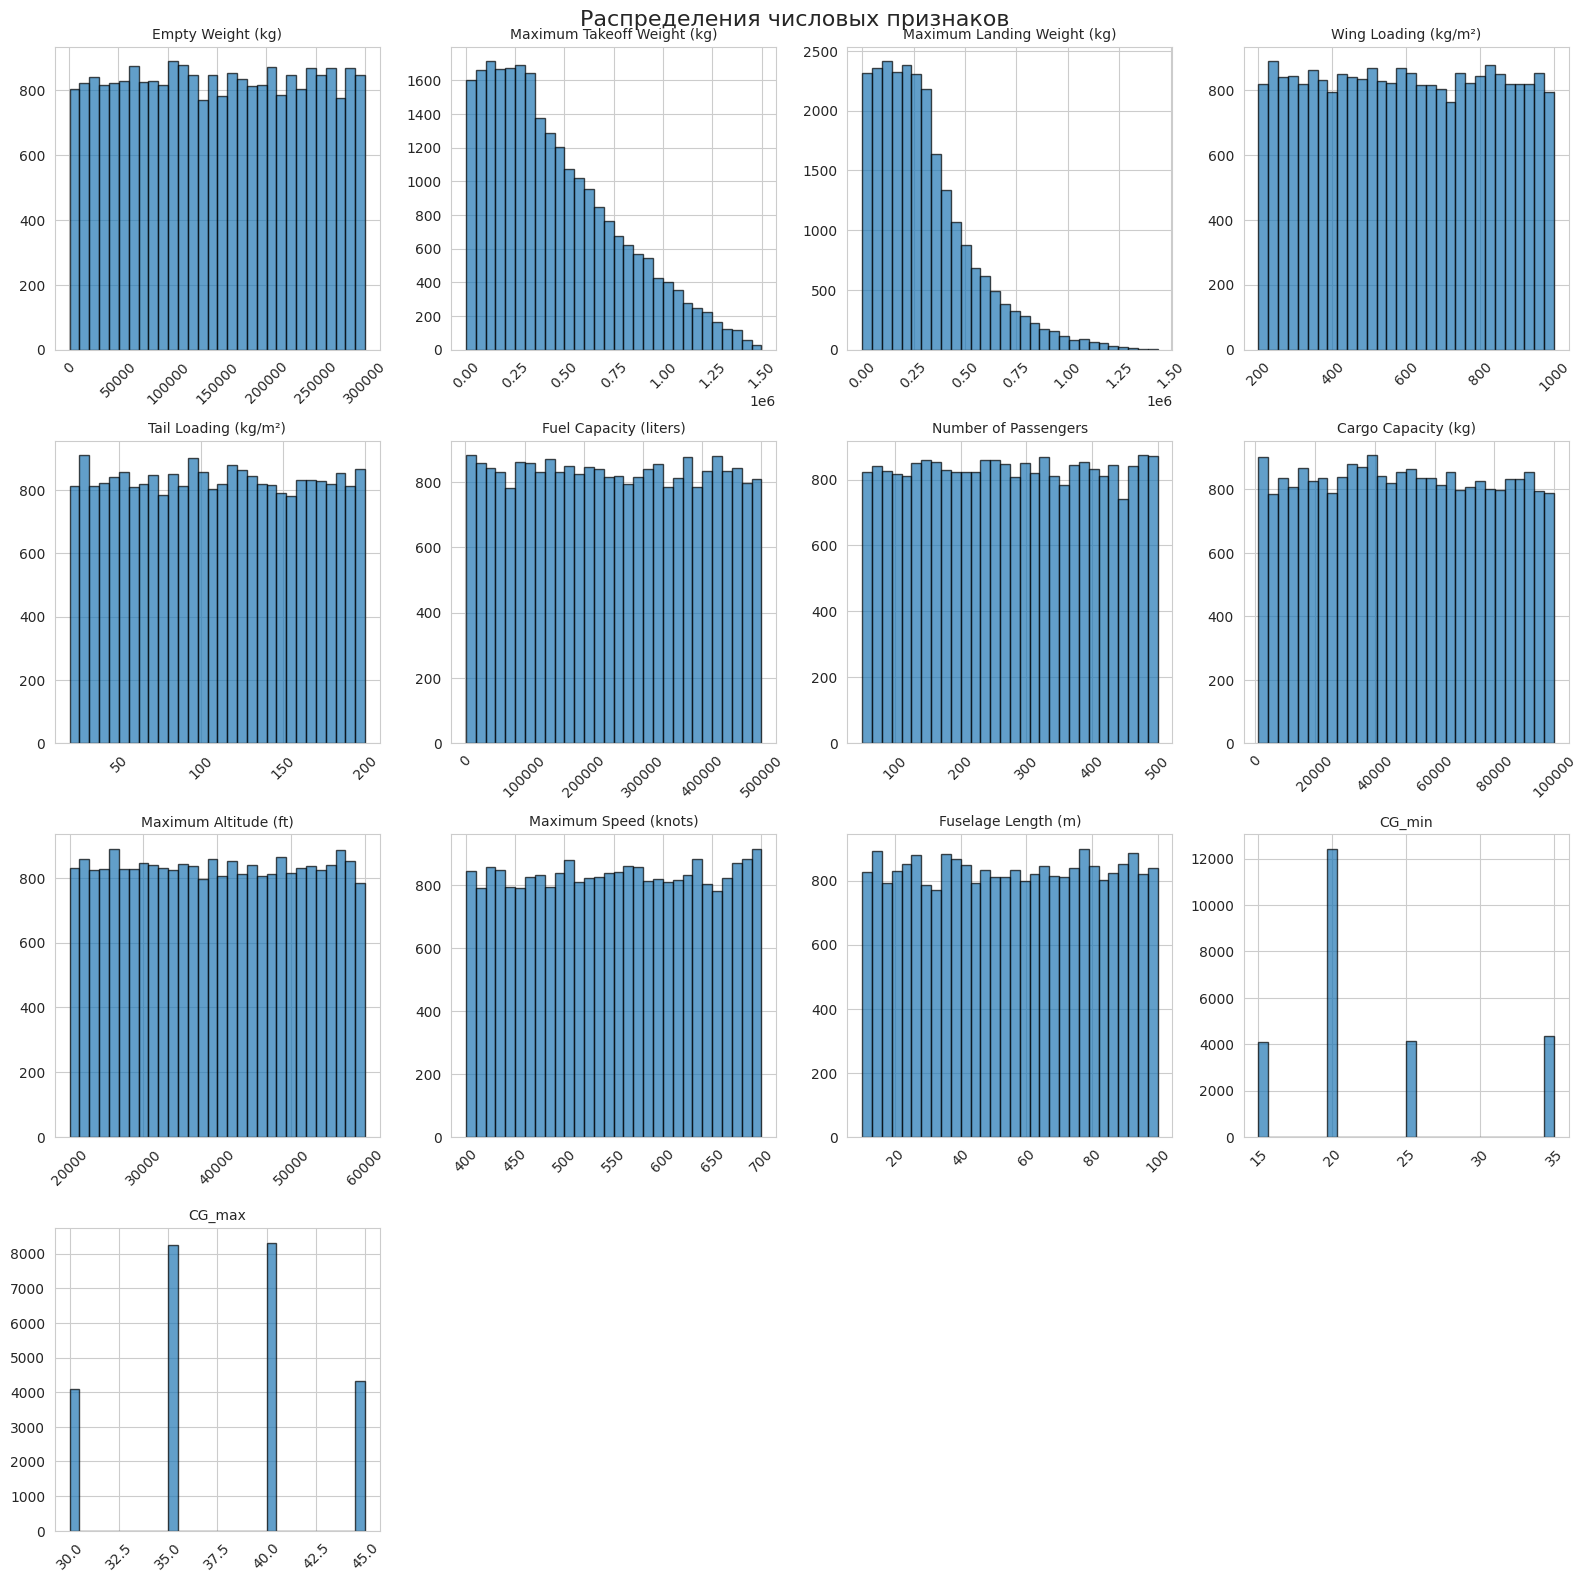

In [4]:
# Гистограммы для всех числовых признаков
cols_per_row = 4
n_rows = math.ceil(len(numeric_cols) / cols_per_row)
fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(16, 4 * n_rows))

if n_rows > 1:
    axes_flat = axes.flatten()
else:
    axes_flat = axes if isinstance(axes, (np.ndarray, list)) else [axes]

for i, col in enumerate(numeric_cols):
    axes_flat[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes_flat[i].set_title(col, fontsize=10)
    axes_flat[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Распределения числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

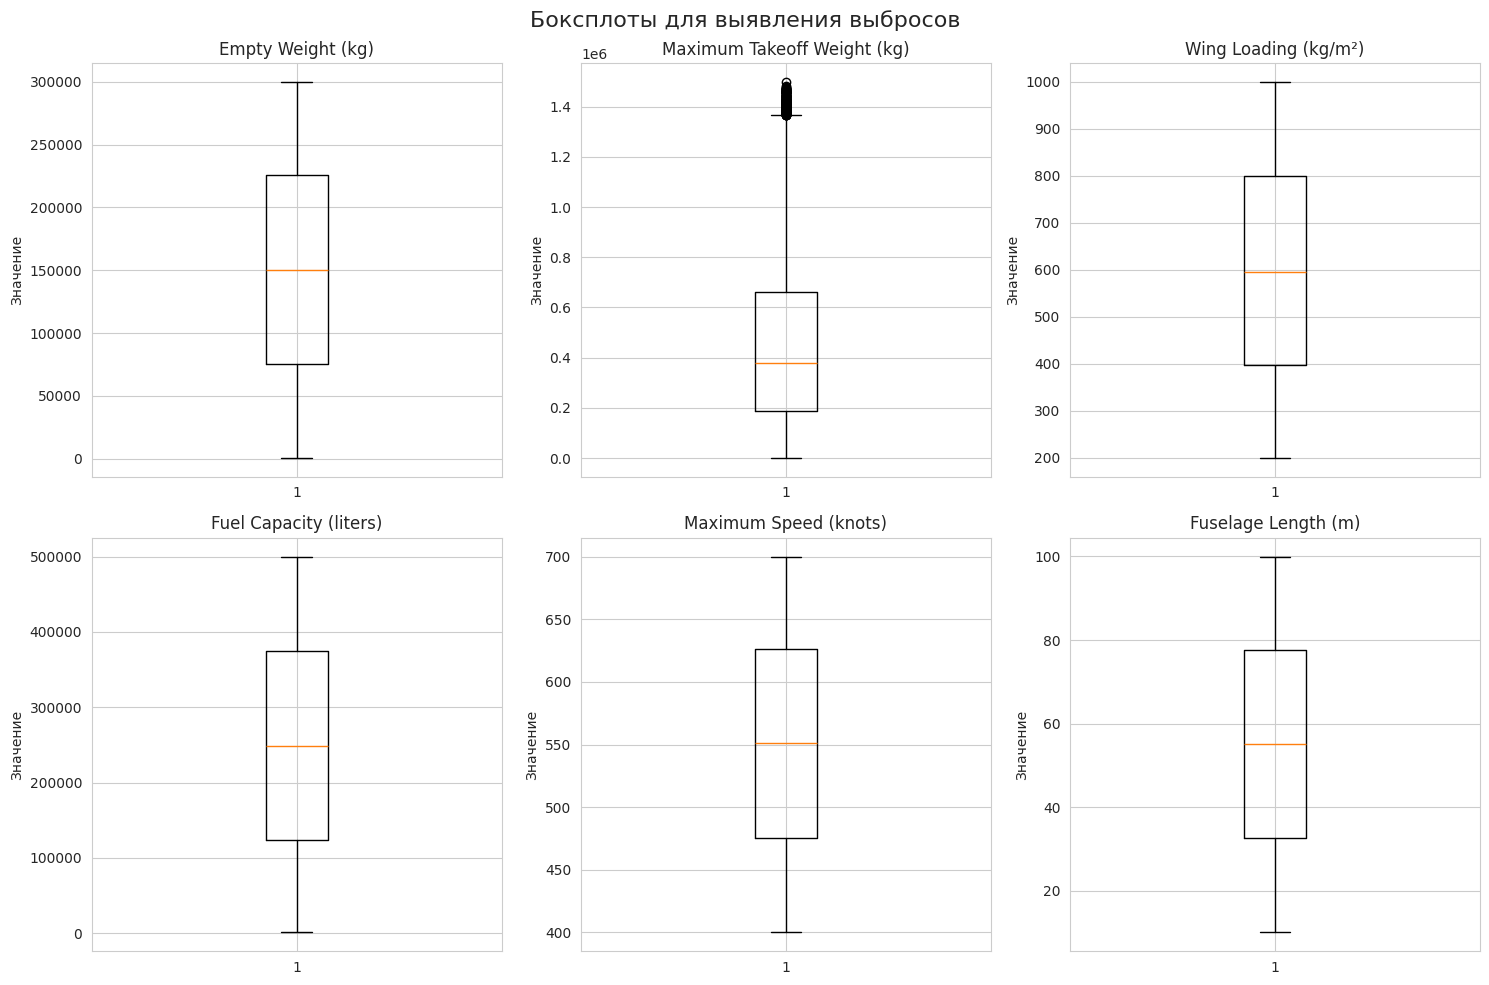

In [5]:
# Боксплоты для выявления выбросов (для избранных признаков)
selected = ['Empty Weight (kg)', 'Maximum Takeoff Weight (kg)', 'Wing Loading (kg/m²)',
            'Fuel Capacity (liters)', 'Maximum Speed (knots)', 'Fuselage Length (m)']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, col in enumerate(selected):
    ax = axes[i//3, i%3]
    ax.boxplot(df[col])
    ax.set_title(col)
    ax.set_ylabel('Значение')
plt.suptitle('Боксплоты для выявления выбросов', fontsize=16)
plt.tight_layout()
plt.show()

/tmp/ipykernel_450215/1670365180.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


Категориальные признаки: ['Aircraft Model', 'Engine Type']


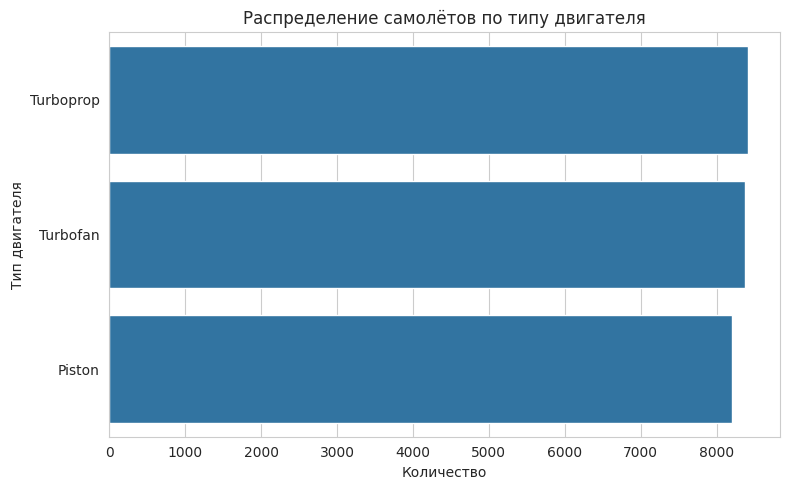

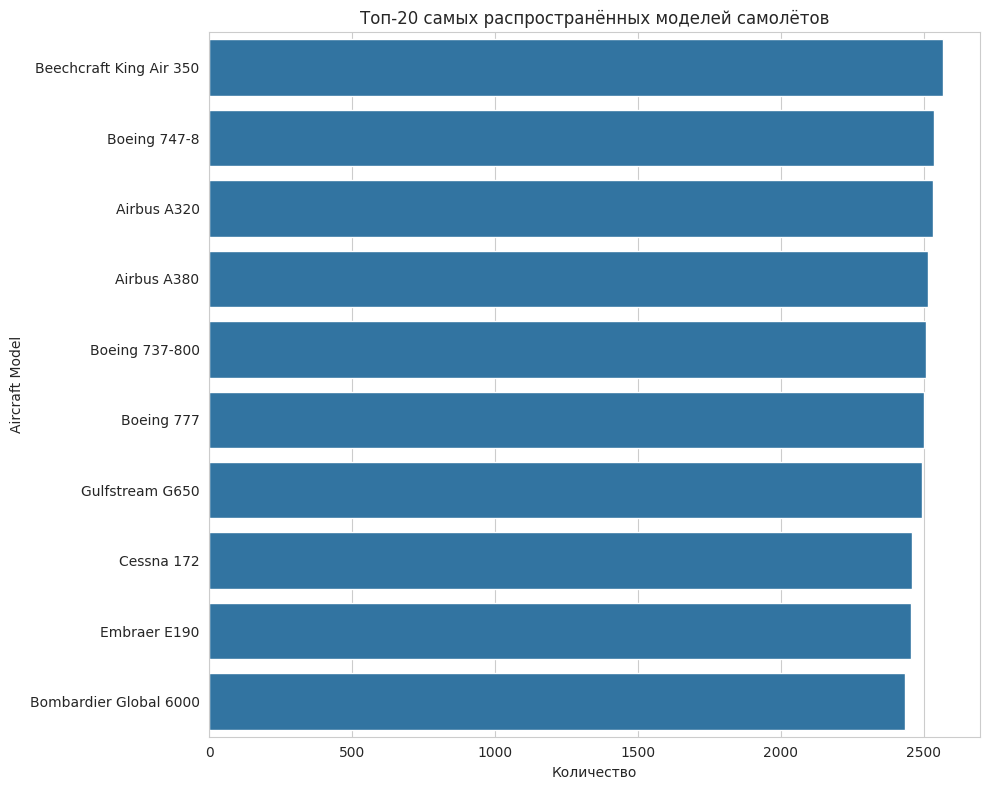

In [6]:
# Анализ категориальных признаков
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Категориальные признаки:", cat_cols)

# Распределение по типу двигателя
plt.figure(figsize=(8, 5))
sns.countplot(y='Engine Type', data=df, order=df['Engine Type'].value_counts().index)
plt.title('Распределение самолётов по типу двигателя')
plt.xlabel('Количество')
plt.ylabel('Тип двигателя')
plt.tight_layout()
plt.show()

# Топ-20 моделей
top_models = df['Aircraft Model'].value_counts().head(20).index
plt.figure(figsize=(10, 8))
sns.countplot(y='Aircraft Model', data=df[df['Aircraft Model'].isin(top_models)],
              order=top_models)
plt.title('Топ-20 самых распространённых моделей самолётов')
plt.xlabel('Количество')
plt.tight_layout()
plt.show()

## 5. Оценка зависимостей между признаками

### 5.1 Матрица корреляции

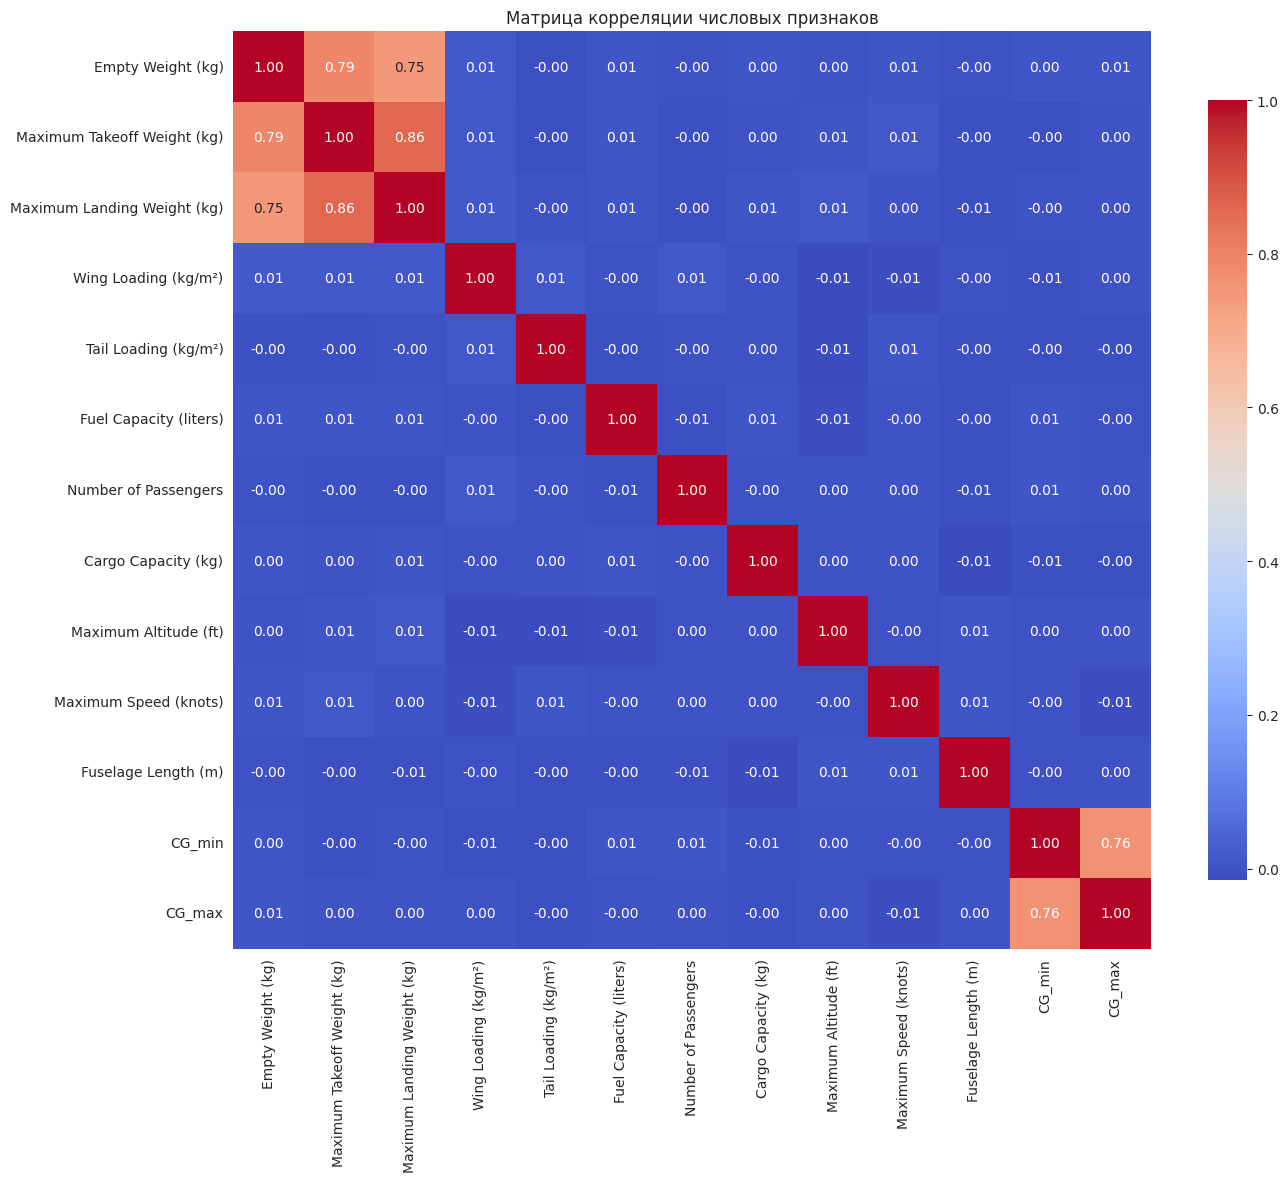

In [7]:
plt.figure(figsize=(14, 12))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляции числовых признаков')
plt.tight_layout()
plt.show()

### 5.2 Зависимость целевой переменной от других признаков

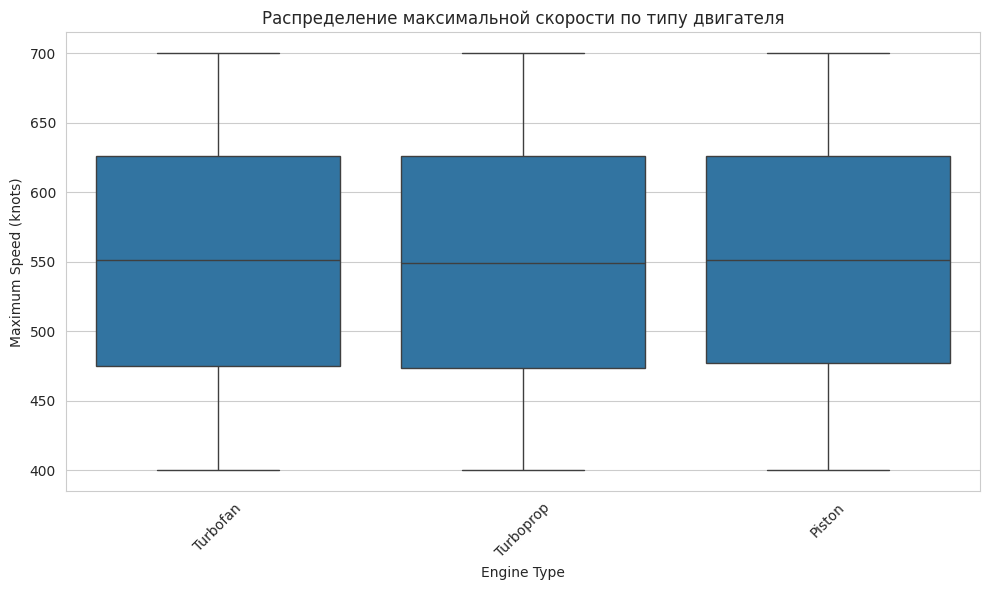

In [9]:
# Влияние типа двигателя на скорость
plt.figure(figsize=(10, 6))
sns.boxplot(x='Engine Type', y=target, data=df)
plt.title('Распределение максимальной скорости по типу двигателя')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Инжиниринг признаков (Feature Engineering)

Создадим новые признаки, которые могут быть полезны при построении моделей:
- `Payload Ratio` — отношение полезной нагрузки к пустому весу.
- `Fuel per Passenger` — количество топлива на одного пассажира.
- `Wing Loading Category` — категория нагрузки на крыло (низкая, средняя, высокая).

In [10]:
df['Payload Ratio'] = (df['Maximum Takeoff Weight (kg)'] - df['Empty Weight (kg)']) / df['Empty Weight (kg)']
df['Fuel per Passenger'] = df['Fuel Capacity (liters)'] / (df['Number of Passengers'] + 1)  # +1 для защиты от деления на ноль
df['Wing Loading Category'] = pd.cut(df['Wing Loading (kg/m²)'], bins=3,
                                      labels=['Low', 'Medium', 'High'])

print("Новые признаки добавлены.")
display(df[['Payload Ratio', 'Fuel per Passenger', 'Wing Loading Category']].head())

Новые признаки добавлены.


,Payload Ratio,Fuel per Passenger,Wing Loading Category
0,0.863896,111.074495,High
1,0.029813,1155.039791,Low
2,2.538125,1019.070836,High
3,3.506542,115.082315,Low
4,2.856604,8833.258951,Medium


## 7. Сохранение очищенных данных

In [11]:
df.to_csv('aircraft_clean.csv', index=False)
print("Очищенный датасет сохранён в файл 'aircraft_clean.csv'")

Очищенный датасет сохранён в файл 'aircraft_clean.csv'


## 8. Ключевые выводы

1. **Качество данных:** данные не содержат пропусков, после очистки удалены только дубликаты и некорректные записи. Все признаки имеют корректные типы.
2. **Распределения:** Несколько числовых признаков(*Maximum Takeoff Weight* и *Maximum Landing Weight*) имеют скошенное распределение, что может потребовать преобразований (логарифмирование) для некоторых моделей.
3. **Корреляции:**
    - Empty Weight, Maximum Takeoff Weight, Maximum Landing Weight
    - Center of Gravity Limits
4. **Инжиниринг признаков:** созданы новые признаки, которые могут улучшить предсказательные модели.

Датасет готов к построению моделей машинного обучения (регрессия для предсказания скорости).